#ACTVIDAD 1

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import random
from sklearn.metrics import classification_report

In [44]:
# Cargar el archivo CSV
df = pd.read_csv('/content/drive/MyDrive/Aprendizaje - Automatico/C4/pib_banco_mundial_50.csv', sep=';')

# Mostrar las primeras filas
df.head()

,Country Name,Country Code,2019,2020,2021,2022,2023
0,Argentina,ARG,1.492100e+12,5.090000e+11,2.781000e+11,7.350000e+11,1.361300e+12
1,Brazil,BRA,8.961000e+11,2.279500e+12,1.978400e+12,1.322700e+12,1.234500e+12
2,United States,USA,2.164700e+12,6.277000e+11,6.323000e+11,1.705900e+12,1.531200e+12
3,China,CHN,8.600000e+09,1.491000e+11,1.204200e+12,2.200000e+12,9.592000e+11
4,India,IND,8.261000e+11,1.537000e+12,2.098200e+12,2.001300e+12,1.486400e+12


In [45]:
# Separar la fila "World" para prueba
df_paises = df[df['Country Name'] != 'World']  # países
pib_mundial = df[df['Country Name'] == 'World']  # WWorld

# Entrenamos con 2019-2022 80%
X_train = df_paises[['2019', '2020', '2021', '2022']].T
y_train = pib_mundial[['2019', '2020', '2021', '2022']].values.flatten()

# Crearmos y entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predecimos el PIB mundial de 2023 20%
X_test = df_paises[['2023']].T
prediccion = modelo.predict(X_test)[0]

# Calculamos y mostramos el R²
y_pred_entrenamiento = modelo.predict(X_train)  # Predicciones sobre los datos de entrenamiento
r2 = r2_score(y_train, y_pred_entrenamiento)    # Calculamos el R²
print(f" Coeficiente de Determinación (R²): {r2:.4f}")

# Resultados
pib_real_2023 = pib_mundial['2023'].values[0]
print(f" PIB Mundial REAL en 2023: {pib_real_2023:,.0f}")
print(f" PIB Mundial PREDICHO en 2023: {prediccion:,.0f}")

 Coeficiente de Determinación (R²): 1.0000
 PIB Mundial REAL en 2023: 69,480,900,000,000
 PIB Mundial PREDICHO en 2023: 60,864,949,172,179


#Calculamos R2 para 5 casos al azar entre 2 paises.

In [46]:
# Separar la fila "World"
df_paises = df[df['Country Name'] != 'World']
pib_mundial = df[df['Country Name'] == 'World']

# Definimos los años
años_entrenamiento = ['2019', '2020', '2021', '2022']

# Función para calcular R² para 2 paises al azar
def r2_paises_azar():

    # Obtenemos la lista de todos los países
    lista_paises = df_paises['Country Name'].tolist()

    # Elegimos 2 países al azar
    paises_azar = random.sample(lista_paises, 2)

    # Filtramos el DataFrame para incluir solo esos 2 países
    df_filtrado = df_paises[df_paises['Country Name'].isin(paises_azar)]

    # PIB de los 2 países en los años de entrenamiento
    X_train = df_filtrado[años_entrenamiento].T
    y_train = pib_mundial[años_entrenamiento].values.flatten()

    # Entrenammos el modelo
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    # Calculamos R²
    y_pred = modelo.predict(X_train)
    r2 = r2_score(y_train, y_pred)

    return paises_azar, r2

# Ejecutamos la función 5 veces y mostramos los resultados
print(" 5 grupos de paises al azar:\n")
resultados = []

for i in range(5):
    paises, r2 = r2_paises_azar()
    print(f"Ejemplo {i+1}: Países = {paises[0]} + {paises[1]} → R² = {r2:.4f}")



 5 grupos de paises al azar:

Ejemplo 1: Países = Peru + Uruguay → R² = 0.3155
Ejemplo 2: Países = Pakistan + United States → R² = 0.8063
Ejemplo 3: Países = Singapore + France → R² = 0.4218
Ejemplo 4: Países = South Africa + Spain → R² = 0.5959
Ejemplo 5: Países = United Arab Emirates + Japan → R² = 0.9012


#ACTIVIDAD 2

In [47]:
# Cargar el archivo CSV
df = pd.read_csv('/content/drive/MyDrive/Aprendizaje - Automatico/C4/usuarios_win_mac_lin.csv')

# Mostramos las primeras filas
print("Primeras filas del dataset")
print(df.head())

# Mostramos la distribucion de las clases
print("\nDistribucion de las clases")
print(df['clase'].value_counts())

Primeras filas del dataset
   duracion  paginas  acciones  valor  clase
0       7.0        2         4      8      2
1      21.0        2         6      6      2
2      57.0        2         4      4      2
3     101.0        3         6     12      2
4     109.0        2         6     12      2

Distribucion de las clases
clase
0    86
2    44
1    40
Name: count, dtype: int64


In [48]:
# Verificar que todas las columnas sean numéricas
df = df.apply(pd.to_numeric, errors='coerce')
print(f"Tipos de datos:\n{df.dtypes}")

Tipos de datos:
duracion    float64
paginas       int64
acciones      int64
valor         int64
clase         int64
dtype: object


In [49]:
# Creacion de Arrays
# Variable X
X = df[['duracion','paginas','acciones','valor']].values

# Variable Y
Y = df['clase'].values

In [50]:
# Entrenamiento 80% Prueba 20%
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [51]:
# Entrenamiento
modelo_l = LogisticRegression(max_iter=1000, multi_class='multinomial')
modelo_l.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [52]:
# Probamos el modelo con el 20%
Y_pred = modelo_l.predict(X_test)

# Calculamos la precision en %
print(f"Precision del modelo: {modelo_l.score(X_test, Y_test):.4f}")

Precision del modelo: 0.6765


In [53]:
# Matriz de Confusion

matriz = confusion_matrix(Y_test, Y_pred)
print("Matriz de Confusión:")
print(matriz)

Matriz de Confusión:
[[13  2  1]
 [ 8  4  0]
 [ 0  0  6]]


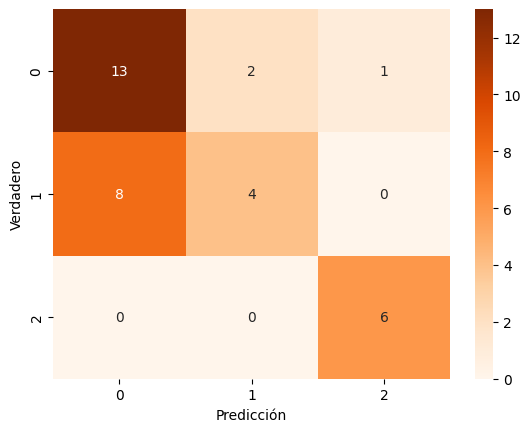


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.62      0.81      0.70        16
           1       0.67      0.33      0.44        12
           2       0.86      1.00      0.92         6

    accuracy                           0.68        34
   macro avg       0.71      0.72      0.69        34
weighted avg       0.68      0.68      0.65        34



In [54]:
# Matriz de Confusion Grafico

sns.heatmap(matriz, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.show()

# Clasificacion

print("\nReporte de Clasificación:")
print(classification_report(Y_test, Y_pred))

# Con datos Aleatorios.

In [55]:
# Asignamos el tamaño del dataset y sus partes
n_samples = 200

duracion = np.random.randint(1, 3500, size=n_samples)
paginas = np.random.randint(1, 10, size=n_samples)
acciones = np.random.randint(1, 60, size=n_samples)
valor = np.random.randint(1, 400, size=n_samples)
clase = np.random.choice([0, 1, 2], size=n_samples)

df = pd.DataFrame({
    'duracion': duracion,
    'paginas': paginas,
    'acciones': acciones,
    'valor': valor,
    'clase': clase
})

# Creamos de nuevo el modelo
print("Primeras filas del dataset")
print(df.head())

print("\nDistribucion de las clases")
print(df['clase'].value_counts())

df = df.apply(pd.to_numeric, errors='coerce')
print(f"Tipos de datos:\n{df.dtypes}")

Primeras filas del dataset
   duracion  paginas  acciones  valor  clase
0      1329        5        14    126      2
1      1265        6        50    374      1
2      2997        3        18     75      0
3      1509        7        51     21      1
4      1473        4        32    310      1

Distribucion de las clases
clase
1    75
2    69
0    56
Name: count, dtype: int64
Tipos de datos:
duracion    int64
paginas     int64
acciones    int64
valor       int64
clase       int64
dtype: object



Precision del modelo: 0.5250

Matriz de Confusión:
[[ 6  0  6]
 [ 0 10  7]
 [ 2  4  5]]


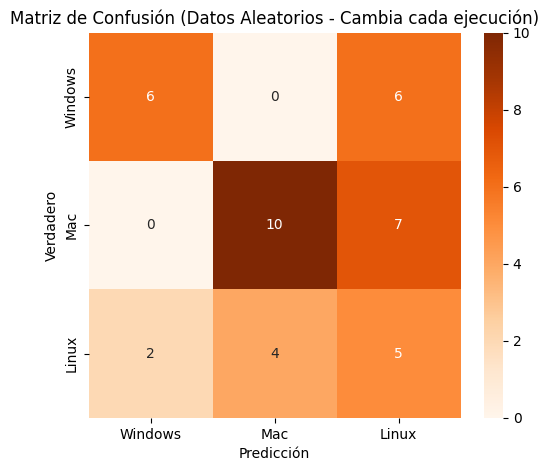


Reporte de Clasificación:
              precision    recall  f1-score   support

     Windows       0.75      0.50      0.60        12
         Mac       0.71      0.59      0.65        17
       Linux       0.28      0.45      0.34        11

    accuracy                           0.53        40
   macro avg       0.58      0.51      0.53        40
weighted avg       0.60      0.53      0.55        40



In [56]:
# Entrenamos el modelo y Creammos mmatriz de confusion con los datos necesarios
X = df[['duracion','paginas','acciones','valor']].values
Y = df['clase'].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

modelo_l = LogisticRegression(max_iter=2000)
modelo_l.fit(X_train, Y_train)

Y_pred = modelo_l.predict(X_test)

print(f"\nPrecision del modelo: {modelo_l.score(X_test, Y_test):.4f}")

matriz = confusion_matrix(Y_test, Y_pred)
print("\nMatriz de Confusión:")
print(matriz)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Oranges",
            xticklabels=['Windows', 'Mac', 'Linux'],
            yticklabels=['Windows', 'Mac', 'Linux'])
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión (Datos Aleatorios - Cambia cada ejecución)")
plt.show()

print("\nReporte de Clasificación:")
print(classification_report(Y_test, Y_pred, target_names=['Windows', 'Mac', 'Linux']))

#Librerias Usadas:

Pandas: Cargar, Manipular y analizar datos en formato tabular.

Numpy: Operaciones numéricas con arreglos y matrices.

Matplotlib.pyplot y Seaborn: Gráficos y visualizaciones.

Scikit-learn: Libreria de machine learning en python. Crear modelos Regresión lineal y logística. Dividir datos en conjuntos entrenamiento y prueba. Evaluar el rendimiento de los modelos con métricas como R2, matriz de confusión.

Random: Para seleccionar países al azar.

# Funciones Usadas:

pd.read_csv(): Cargar archivos formato csv.

train_test_split(): Dividir los datos 80/20(Entrenamiento/Prueba).

linearRegression(): Crear modelo de Regresión Lineal.

modelo.fit(): Entrenar el modelo.

modelo.predict(): Hacer predicciones con datos.

r2_score(): Calcula el coeficiente de determinación R2 (Que tan bien el modelo explica la variabilidad de los datos) siendo 1.0 = perfecto.

logisticRegression(): Crear el modelo de clasificación.

modelo_1.predict(): Predecir la clase (Win,Mac,Lin).

confusion_matrix() y sns.heatmap(): Visualizar los aciertos y errores del modelo

classificacion_report(): Mostrar métricas detalladas por clase.

# Actividad 1:

Se logro predecir el PIB mundial de 2023 usando el PIB de los países.

Este modelo dio como resultado un R2= 1.0, lo que indica un ajuste perfecto, teniendo en cuenta que es un dataset creado era una posibilidad esperar este resultado.

En el segundo modelo se puede observar 5 ejemplo de países elegidos al azar con valores más reales.

# Actividad 2:

El modelo de regresión logística logro clasificar a los usuarios según el sistema operativo con una precisión de 67% esto quiere decir que son buenas opciones, pero quizás no las suficientes o indicadas en su totalidad para realizar esta clasificación.

Por otro lado, la matriz de confusión mostro de forma gráfica el desempeño de esta clasificación.

Como segundo ejercicio creamos un modelo aleatorio donde se puede ver de qué forma varia tanto el porcentaje de precisión como la matriz de confusión,
